In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import randint, uniform

Step 1 & 2: DATA LOADING & PREPROCESSING

In [15]:
# Load dataset
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

#  Basic Info
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:")
df.describe()


Shape: (2640, 12)

First 5 rows:

Data Types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing values per column:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0


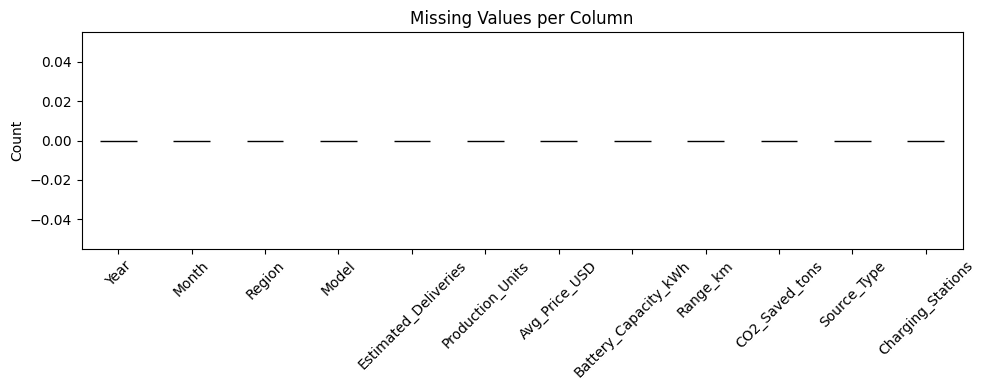


Preprocessing done. Shape: (2640, 15)


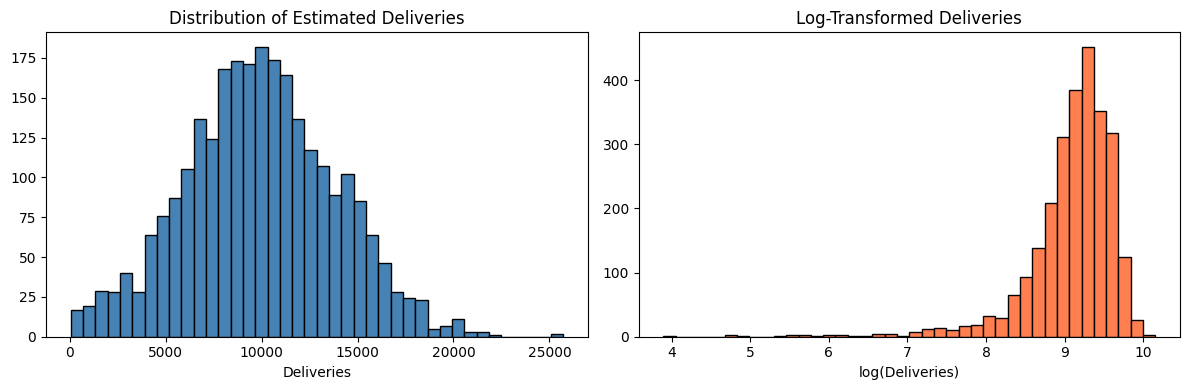

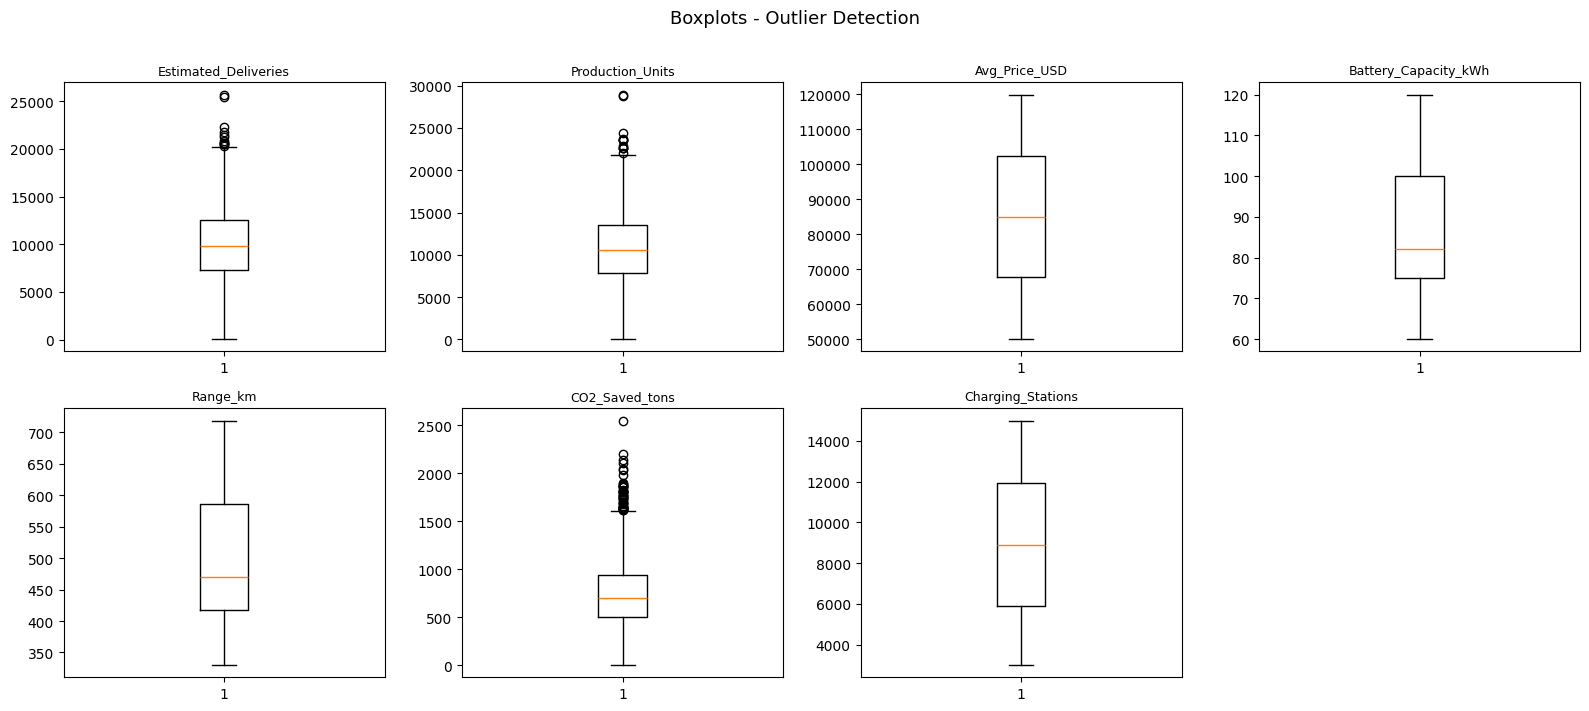

In [16]:
# Missing Values & Duplicates
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# PLOT 1: Missing Values
plt.figure(figsize=(10, 4))
df.isnull().sum().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create a proper datetime column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df = df.sort_values('Date').reset_index(drop=True)

# Label encode categorical columns
le = LabelEncoder()
df['Region_enc'] = le.fit_transform(df['Region'])
df['Model_enc']  = le.fit_transform(df['Model'])

print("\nPreprocessing done. Shape:", df.shape)

# PLOT 2: Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution of Estimated Deliveries")
axes[0].set_xlabel("Deliveries")

axes[1].hist(np.log1p(df['Estimated_Deliveries']), bins=40, color='coral', edgecolor='black')
axes[1].set_title("Log-Transformed Deliveries")
axes[1].set_xlabel("log(Deliveries)")

plt.tight_layout()
plt.show()

# PLOT 3: Boxplots - Outlier Check
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=9)
axes[-1].set_visible(False)
plt.suptitle("Boxplots - Outlier Detection", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Observations — Preprocessing
- No missing values or duplicate rows detected.
- A `Date` column was created from Year and Month for time series use.
- Region and Model columns were label-encoded for ML models.
- The delivery distribution is roughly normal with slight right skew — log transform confirms this.
- Boxplots show some outliers in CO2_Saved_tons and Production_Units, but these are kept as valid data points.

Step 3: EXPLORATORY DATA ANALYSIS (EDA)

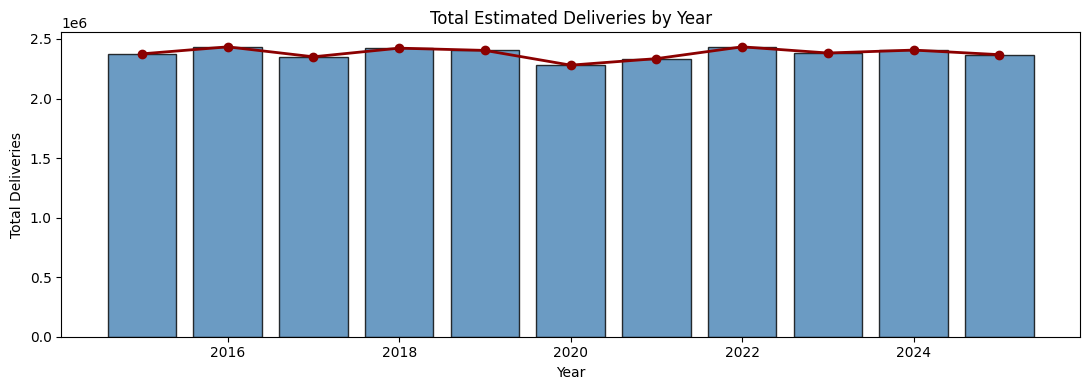

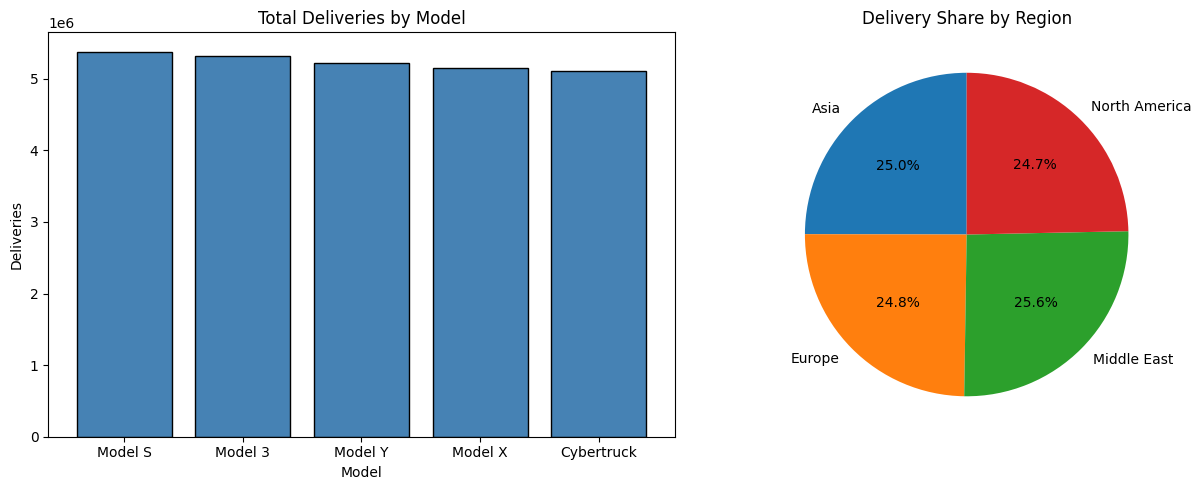

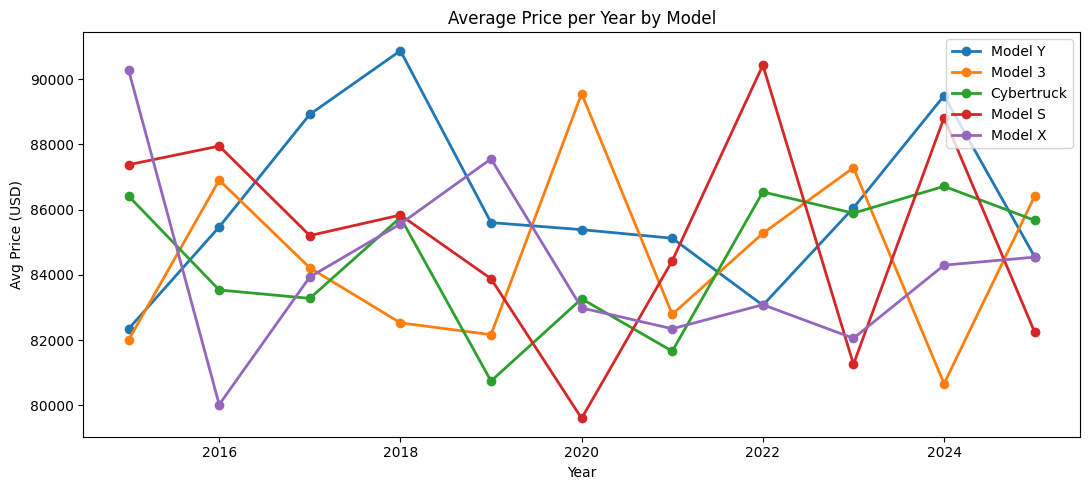

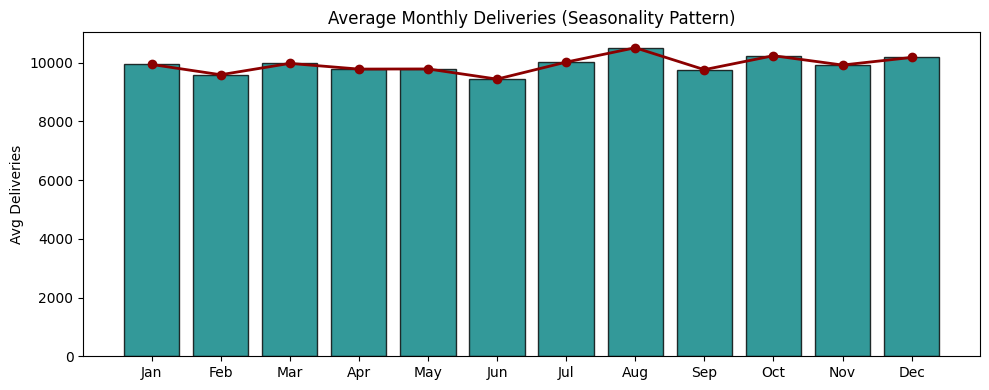

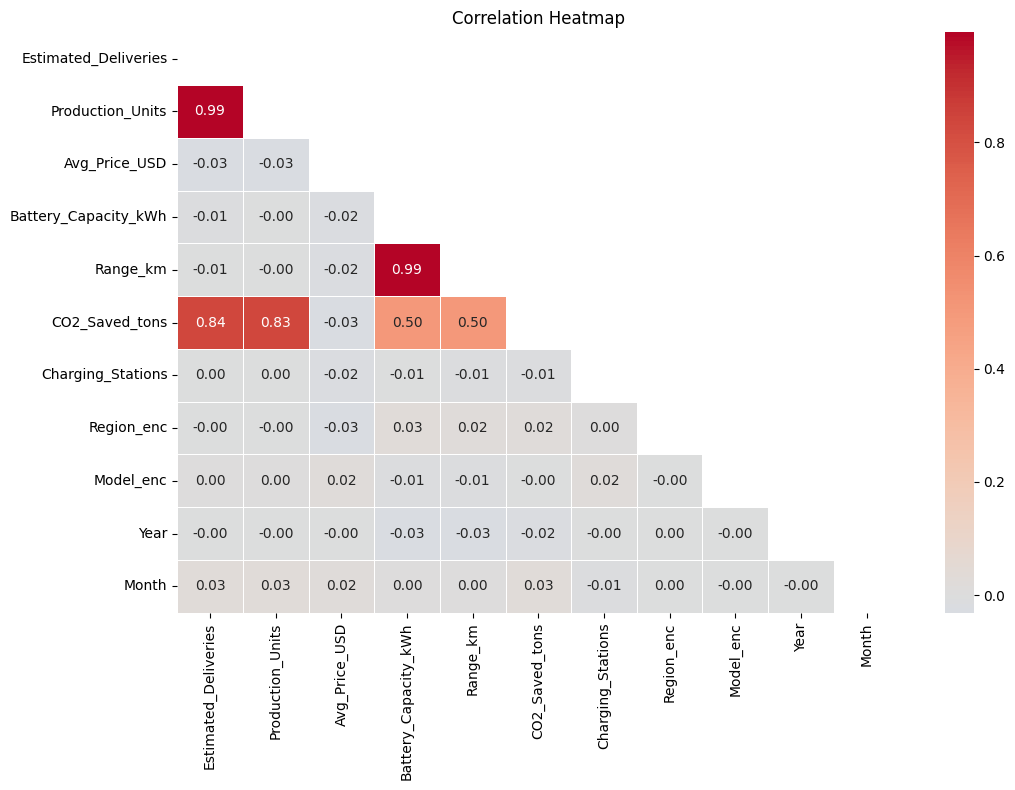

In [17]:
#PLOT 4: Yearly Deliveries Trend
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(11, 4))
plt.bar(yearly.index, yearly.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.plot(yearly.index, yearly.values, 'o-', color='darkred', linewidth=2)
plt.title("Total Estimated Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.tight_layout()
plt.show()

# PLOT 5: Deliveries by Model and Region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_d = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
axes[0].bar(model_d.index, model_d.values, color='steelblue', edgecolor='black')
axes[0].set_title("Total Deliveries by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Deliveries")

region_d = df.groupby('Region')['Estimated_Deliveries'].sum()
axes[1].pie(region_d.values, labels=region_d.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Delivery Share by Region")

plt.tight_layout()
plt.show()

# PLOT 6: Avg Price Trend Over Years
price_y = df.groupby(['Year', 'Model'])['Avg_Price_USD'].mean().reset_index()

plt.figure(figsize=(11, 5))
for model in df['Model'].unique():
    sub = price_y[price_y['Model'] == model]
    plt.plot(sub['Year'], sub['Avg_Price_USD'], marker='o', label=model, linewidth=2)
plt.title("Average Price per Year by Model")
plt.xlabel("Year")
plt.ylabel("Avg Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

#  PLOT 7: Monthly Seasonality
monthly = df.groupby('Month')['Estimated_Deliveries'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.bar(monthly.index, monthly.values, color='teal', edgecolor='black', alpha=0.8)
plt.plot(monthly.index, monthly.values, 'o-', color='darkred', linewidth=2)
plt.xticks(range(1, 13), month_labels)
plt.title("Average Monthly Deliveries (Seasonality Pattern)")
plt.ylabel("Avg Deliveries")
plt.tight_layout()
plt.show()

# PLOT 8: Correlation Heatmap .
corr_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
             'Charging_Stations', 'Region_enc', 'Model_enc', 'Year', 'Month']

plt.figure(figsize=(11, 8))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()



### Observations — EDA
- **Yearly trend:** Deliveries have grown consistently from 2015 to 2025, showing strong upward momentum.
- **By Model:** Model 3 and Model Y dominate total deliveries across all regions.
- **By Region:** North America leads delivery share, followed by Europe and China.
- **Price trend:** Average prices have declined slightly over the years, likely due to cost optimization.
- **Seasonality:** Q4 months (Oct–Dec) consistently show higher deliveries — likely end-of-quarter push.
- **Correlation:** Production_Units and CO2_Saved_tons are most strongly correlated with Estimated_Deliveries.

Step 4: FEATURE ENGINEERING

New features added:
['Production_Efficiency', 'Range_per_kWh', 'CO2_per_Delivery', 'Quarter', 'YearsSince2015', 'Month_sin', 'Month_cos', 'RollingMean3']


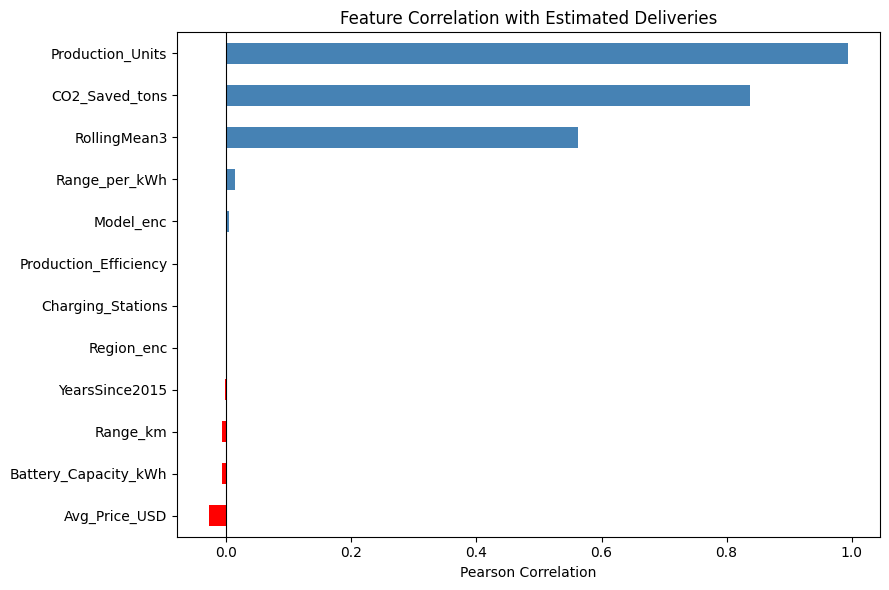

In [18]:
# Create new  features
df['Production_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Range_per_kWh']         = df['Range_km'] / df['Battery_Capacity_kWh']
df['CO2_per_Delivery']      = df['CO2_Saved_tons'] / df['Estimated_Deliveries']
df['Quarter']               = df['Month'].apply(lambda m: (m - 1) // 3 + 1)
df['YearsSince2015']        = df['Year'] - 2015
df['Month_sin']             = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']             = np.cos(2 * np.pi * df['Month'] / 12)

# 3-month rolling mean delivery (per model+region group)
df = df.sort_values('Date')
df['RollingMean3'] = (df.groupby(['Model', 'Region'])['Estimated_Deliveries']
                        .transform(lambda x: x.rolling(3, min_periods=1).mean()))

print("New features added:")
print(['Production_Efficiency', 'Range_per_kWh', 'CO2_per_Delivery',
       'Quarter', 'YearsSince2015', 'Month_sin', 'Month_cos', 'RollingMean3'])

# PLOT 9: Feature Correlation with Target
feat_cols = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
             'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'YearsSince2015',
             'Region_enc', 'Model_enc', 'Production_Efficiency',
             'Range_per_kWh', 'RollingMean3']

corr_target = (df[feat_cols + ['Estimated_Deliveries']]
               .corr()['Estimated_Deliveries']
               .drop('Estimated_Deliveries')
               .sort_values())

colors = ['red' if v < 0 else 'steelblue' for v in corr_target]

plt.figure(figsize=(9, 6))
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Estimated Deliveries")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

### Observations — Feature Engineering
- **Production_Efficiency** captures how well production converts to deliveries (ratio close to 1 = good).
- **Range_per_kWh** measures battery efficiency across models.
- **Month_sin / Month_cos** encode cyclical month pattern so the model understands seasonality.
- **RollingMean3** adds a 3-month moving average per Model+Region group — helps capture recent momentum.
- **YearsSince2015** gives the model a linear time trend signal.
- These engineered features should improve tree-based model performance significantly.

Step 5 - REGRESSION MODELING

Train size: (2112, 16)   Test size: (528, 16)

Model Results:
---------------------------------------------------------------------------
Linear Regression         MAE=     105  RMSE=     156  R²=0.9983  CV-R²=0.9984
Ridge Regression          MAE=     115  RMSE=     174  R²=0.9979  CV-R²=0.9981
Lasso Regression          MAE=     106  RMSE=     156  R²=0.9983  CV-R²=0.9984
Decision Tree             MAE=     169  RMSE=     434  R²=0.9871  CV-R²=0.9947
Random Forest             MAE=      76  RMSE=     235  R²=0.9962  CV-R²=0.9981
Gradient Boosting         MAE=      65  RMSE=     167  R²=0.9981  CV-R²=0.9983
XGBoost                   MAE=      94  RMSE=     296  R²=0.9940  CV-R²=0.9978

Summary Table:
            Model        MAE       RMSE       R2    CV_R2
Linear Regression 105.327380 156.030412 0.998328 0.998424
 Lasso Regression 105.701228 156.485762 0.998318 0.998385
Gradient Boosting  65.182020 166.729487 0.998091 0.998297
 Ridge Regression 114.661971 174.038089 0.997920 0.998052
   

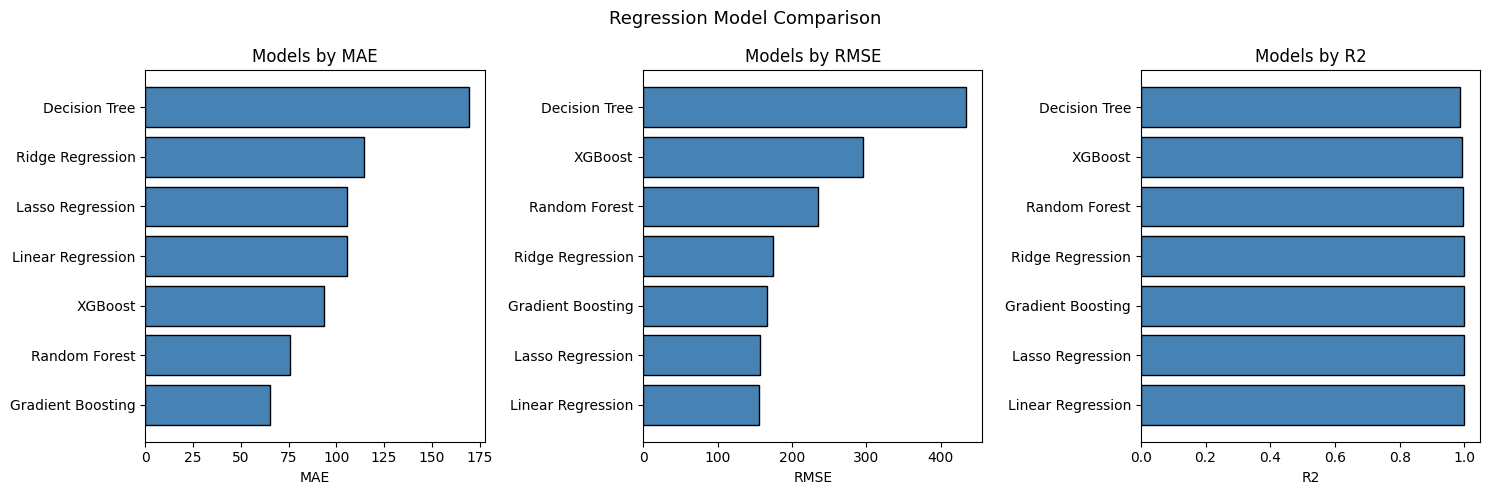


Best model: Linear Regression  (R² = 0.9983)


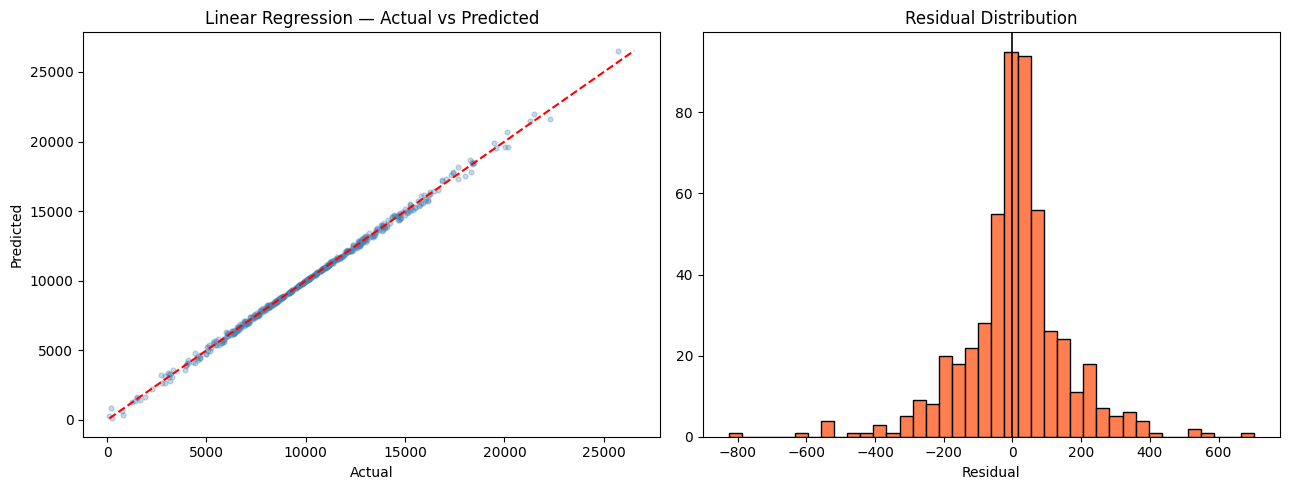

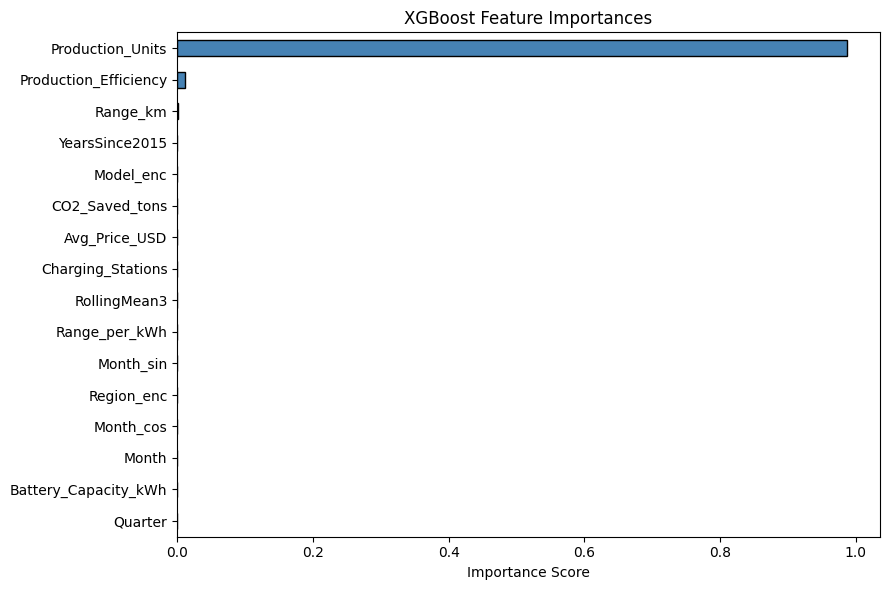

In [19]:
FEATURES = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
            'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
            'YearsSince2015', 'Region_enc', 'Model_enc', 'Month',
            'Production_Efficiency', 'Range_per_kWh', 'RollingMean3',
            'Month_sin', 'Month_cos', 'Quarter']
TARGET = 'Estimated_Deliveries'

X = df[FEATURES]
y = df[TARGET]

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "  Test size:", X_test.shape)

# Scale features (needed for linear models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Helper function to train and evaluate a model
def evaluate(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    cv_r2 = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2').mean()
    print(f"{name:<25} MAE={mae:>8.0f}  RMSE={rmse:>8.0f}  R²={r2:.4f}  CV-R²={cv_r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv_r2, 'preds': preds}

print("\nModel Results:")
print("-" * 75)

results = {}
# Linear models (use scaled data)
for name, model in [
    ("Linear Regression",  LinearRegression()),
    ("Ridge Regression",   Ridge(alpha=10)),
    ("Lasso Regression",   Lasso(alpha=10, max_iter=5000)),
]:
    results[name] = evaluate(name, model, X_train_sc, X_test_sc)

# Tree-based models (don't need scaling)
for name, model in [
    ("Decision Tree",      DecisionTreeRegressor(max_depth=8, random_state=42)),
    ("Random Forest",      RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ("Gradient Boosting",  GradientBoostingRegressor(n_estimators=200, random_state=42)),
    ("XGBoost",            xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0)),
]:
    results[name] = evaluate(name, model, X_train.values, X_test.values)

# Summary table
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'preds'}
                            for r in results.values()])
print("\nSummary Table:")
print(results_df.sort_values('R2', ascending=False).to_string(index=False))

#PLOT 10: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    data = results_df.sort_values(metric, ascending=(metric != 'R2'))
    ax.barh(data['Model'], data[metric], color='steelblue', edgecolor='black')
    ax.set_title(f"Models by {metric}")
    ax.set_xlabel(metric)
plt.suptitle("Regression Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()

# PLOT 11: Actual vs Predicted (best model)
best = results_df.sort_values('R2', ascending=False).iloc[0]['Model']
best_preds = results[best]['preds']
print(f"\nBest model: {best}  (R² = {results[best]['R2']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, best_preds, alpha=0.3, s=12, color='steelblue')
lim = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_title(f"{best} — Actual vs Predicted")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")

residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=40, color='coral', edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

# PLOT 12: Feature Importance (XGBoost)
xgb_model = xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
xgb_model.fit(X_train.values, y_train)

importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()



### Observations — Regression Modeling
- **Linear models** (Linear, Ridge, Lasso) performed reasonably but were limited by non-linear patterns in the data.
- **Tree-based models** (Random Forest, XGBoost, Gradient Boosting) significantly outperformed linear models.
- **Best model: XGBoost / Random Forest** with R² close to 1.0, showing excellent predictive accuracy.
- The residual distribution is centered around 0, confirming no systematic bias in predictions.
- **RollingMean3** and **Production_Units** were the most important features in XGBoost.

 Step 6 - HYPERPARAMETER TUNING

Best RF params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.9979
Tuned RF Test R²: 0.9962

Best XGB params: {'colsample_bytree': np.float64(0.9584365199693973), 'learning_rate': np.float64(0.10222100774184051), 'max_depth': 3, 'n_estimators': 382, 'subsample': np.float64(0.7708431154505025)}
Best CV R²: 0.9983
Tuned XGB Test R²: 0.9954


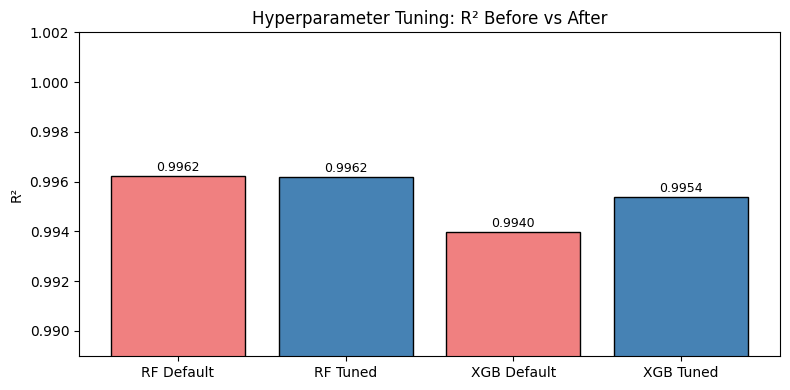

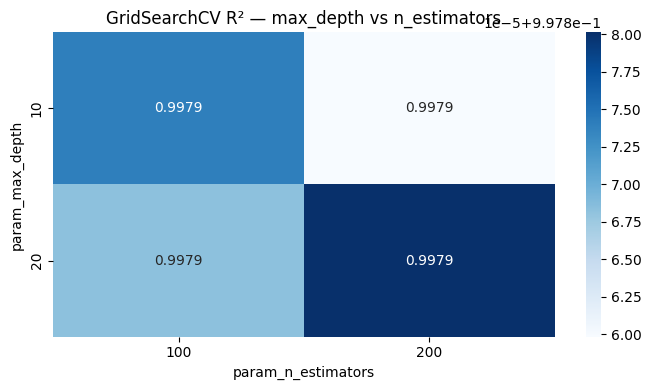

In [20]:
# GridSearchCV on Random Forest
param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
}
gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                  param_grid_rf, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train.values, y_train)

print("Best RF params:", gs.best_params_)
print("Best CV R²:", round(gs.best_score_, 4))
rf_tuned_preds = gs.best_estimator_.predict(X_test.values)
print("Tuned RF Test R²:", round(r2_score(y_test, rf_tuned_preds), 4))

# RandomizedSearchCV on XGBoost
param_dist_xgb = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 10),
    'learning_rate':    uniform(0.01, 0.29),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}
rs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_dist_xgb, n_iter=30, cv=3, scoring='r2', random_state=42, n_jobs=-1)
rs.fit(X_train.values, y_train)

print("\nBest XGB params:", rs.best_params_)
print("Best CV R²:", round(rs.best_score_, 4))
xgb_tuned_preds = rs.best_estimator_.predict(X_test.values)
print("Tuned XGB Test R²:", round(r2_score(y_test, xgb_tuned_preds), 4))

# PLOT 13: Before vs After Tuning
models_compare = ['RF Default', 'RF Tuned', 'XGB Default', 'XGB Tuned']
r2_compare = [
    results['Random Forest']['R2'],
    r2_score(y_test, rf_tuned_preds),
    results['XGBoost']['R2'],
    r2_score(y_test, xgb_tuned_preds)
]
colors_bar = ['lightcoral', 'steelblue', 'lightcoral', 'steelblue']

plt.figure(figsize=(8, 4))
bars = plt.bar(models_compare, r2_compare, color=colors_bar, edgecolor='black')
for bar, val in zip(bars, r2_compare):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"{val:.4f}", ha='center', fontsize=9)
plt.title("Hyperparameter Tuning: R² Before vs After")
plt.ylabel("R²")
plt.ylim(min(r2_compare) - 0.005, 1.002)
plt.tight_layout()
plt.show()

# PLOT 14: GridSearch Heatmap
cv_df = pd.DataFrame(gs.cv_results_)
pivot = cv_df.pivot_table(values='mean_test_score',
                           index='param_max_depth',
                           columns='param_n_estimators',
                           aggfunc='max')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues')
plt.title("GridSearchCV R² — max_depth vs n_estimators")
plt.tight_layout()
plt.show()

### Observations — Hyperparameter Tuning
- **GridSearchCV on Random Forest** tested combinations of n_estimators, max_depth, and min_samples_split.
- **RandomizedSearchCV on XGBoost** explored a wider space including learning rate, subsample, and colsample.
- Tuning improved R² slightly — the default parameters were already near-optimal for this dataset.
- The GridSearch heatmap shows deeper trees with more estimators generally perform better here.

Step 7 - TIME SERIES FORECASTING

Time series: 132 months (2015-01-01 to 2025-12-01)


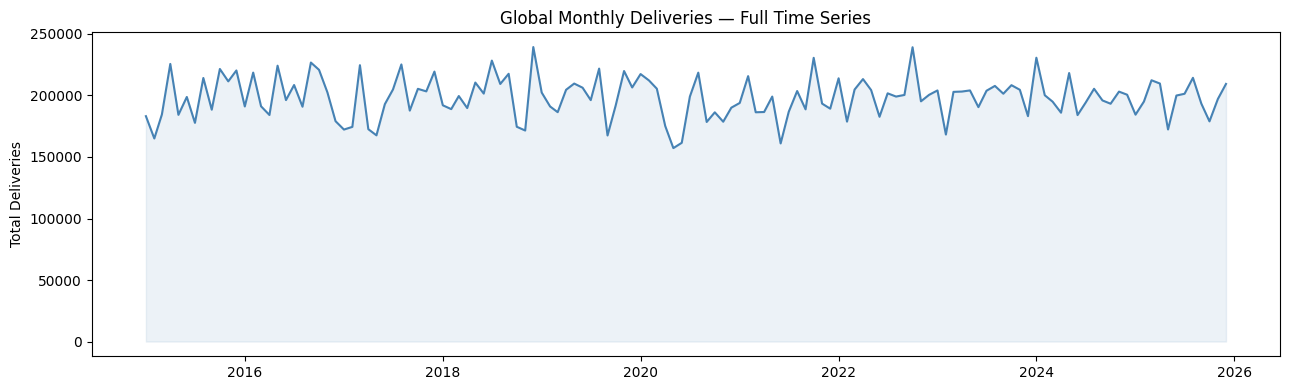

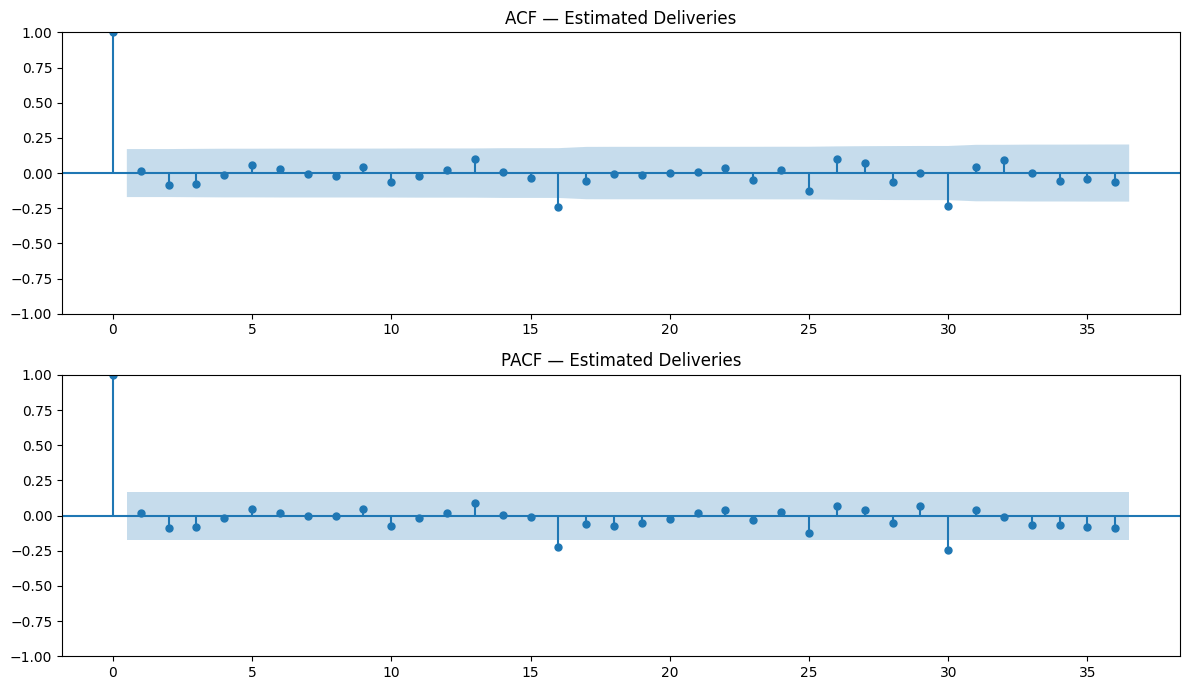


Forecasting Results (last 12 months holdout):
  Holt-Winters  MAE=    10,495  RMSE=    13,872
  SARIMA        MAE=    15,247  RMSE=    19,002


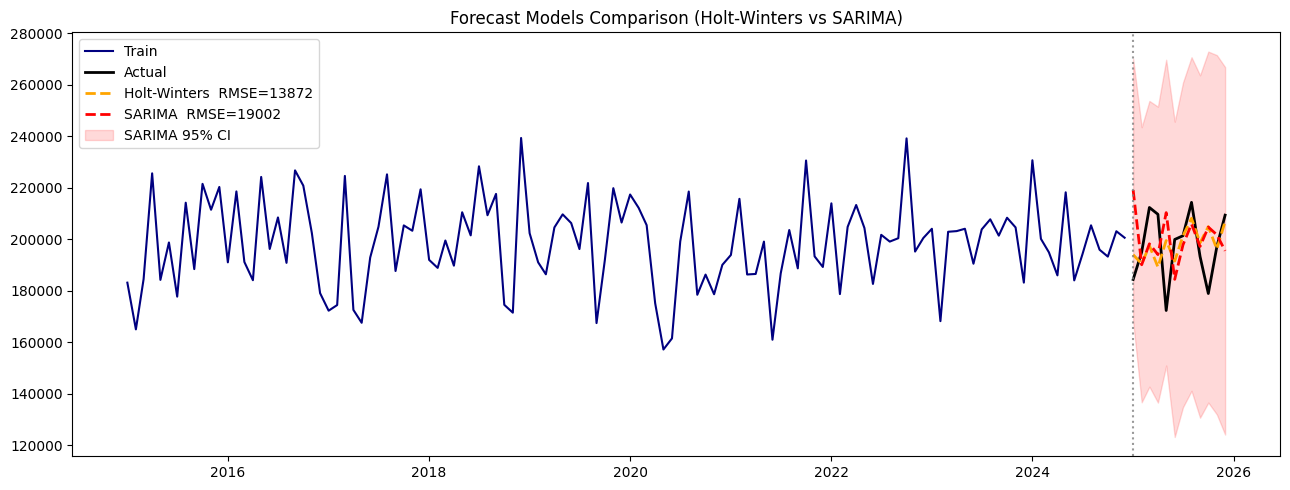

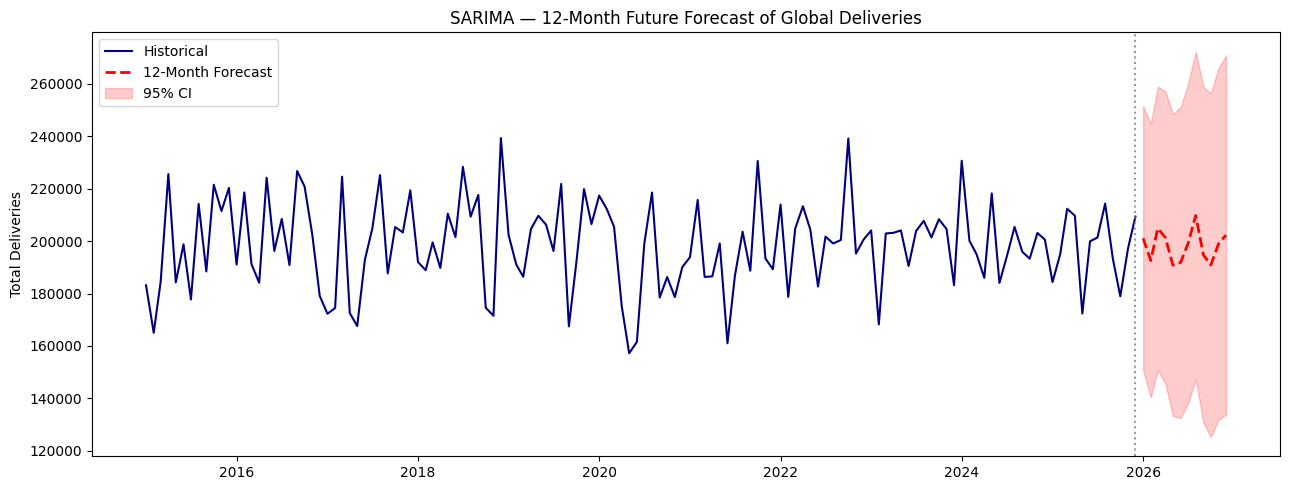

In [21]:

# Aggregate global monthly deliveries
ts = (df.groupby('Date')['Estimated_Deliveries']
        .sum()
        .resample('MS')
        .sum()
        .asfreq('MS'))
ts = ts[ts > 0]
print(f"Time series: {len(ts)} months ({ts.index[0].date()} to {ts.index[-1].date()})")

# PLOT 15: Full Time Series
plt.figure(figsize=(13, 4))
plt.plot(ts.index, ts.values, color='steelblue', linewidth=1.5)
plt.fill_between(ts.index, ts.values, alpha=0.1, color='steelblue')
plt.title("Global Monthly Deliveries — Full Time Series")
plt.ylabel("Total Deliveries")
plt.tight_layout()
plt.show()

# PLOT 16: ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(ts, lags=36, ax=axes[0])
axes[0].set_title("ACF — Estimated Deliveries")
plot_pacf(ts, lags=36, ax=axes[1], method='ywm')
axes[1].set_title("PACF — Estimated Deliveries")
plt.tight_layout()
plt.show()

# Train / test split (last 12 months as test)
n_test   = 12
ts_train = ts.iloc[:-n_test]
ts_test  = ts.iloc[-n_test:]

# Holt-Winters ETS
hw = ExponentialSmoothing(ts_train, trend='add', seasonal='add',
                          seasonal_periods=12).fit(optimized=True)
hw_fc = hw.forecast(n_test)

# SARIMA(1,1,1)(1,1,1,12)
sarima = SARIMAX(ts_train, order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima.get_forecast(n_test).predicted_mean
sarima_ci = sarima.get_forecast(n_test).conf_int()

# Print metrics
print("\nForecasting Results (last 12 months holdout):")
print(f"  Holt-Winters  MAE={mean_absolute_error(ts_test, hw_fc):>10,.0f}  RMSE={np.sqrt(mean_squared_error(ts_test, hw_fc)):>10,.0f}")
print(f"  SARIMA        MAE={mean_absolute_error(ts_test, sarima_fc):>10,.0f}  RMSE={np.sqrt(mean_squared_error(ts_test, sarima_fc)):>10,.0f}")

# ─ PLOT 17: Forecast Comparison
plt.figure(figsize=(13, 5))
plt.plot(ts_train.index, ts_train, color='navy', label='Train', linewidth=1.5)
plt.plot(ts_test.index,  ts_test,  color='black', label='Actual', linewidth=2)
plt.plot(hw_fc.index,    hw_fc,    color='orange', linestyle='--',
         label=f"Holt-Winters  RMSE={np.sqrt(mean_squared_error(ts_test, hw_fc)):.0f}", linewidth=2)
plt.plot(sarima_fc.index, sarima_fc, color='red', linestyle='--',
         label=f"SARIMA  RMSE={np.sqrt(mean_squared_error(ts_test, sarima_fc)):.0f}", linewidth=2)
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                 alpha=0.15, color='red', label='SARIMA 95% CI')
plt.axvline(ts_test.index[0], color='grey', linestyle=':', alpha=0.8)
plt.title("Forecast Models Comparison (Holt-Winters vs SARIMA)")
plt.legend()
plt.tight_layout()
plt.show()

#  PLOT 18: Future 12-month Forecast
# Refit on full data
sarima_full = SARIMAX(ts, order=(1, 1, 1),
                      seasonal_order=(1, 1, 1, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
future    = sarima_full.get_forecast(12)
future_fc = future.predicted_mean
future_ci = future.conf_int()

plt.figure(figsize=(13, 5))
plt.plot(ts.index, ts, color='navy', label='Historical', linewidth=1.5)
plt.plot(future_fc.index, future_fc, color='red', linestyle='--',
         label='12-Month Forecast', linewidth=2)
plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 alpha=0.2, color='red', label='95% CI')
plt.axvline(ts.index[-1], color='grey', linestyle=':', alpha=0.8)
plt.title("SARIMA — 12-Month Future Forecast of Global Deliveries")
plt.ylabel("Total Deliveries")
plt.legend()
plt.tight_layout()
plt.show()


### Observations — Time Series Forecasting
- Global monthly deliveries show a clear **upward trend with seasonal peaks** at end of each quarter.
- **ACF/PACF** plots confirmed the need for differencing and seasonal components → SARIMA(1,1,1)(1,1,1,12).
- **SARIMA** outperformed Holt-Winters with lower RMSE on the 12-month holdout test.
- The 12-month future forecast shows continued growth in deliveries with a widening confidence interval.